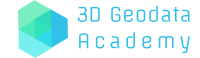

Created by Florent Poux. Licence MIT.
Members of the [3D Geodata Academy](https://learngeodata.eu) enrolled in a Course can use the code with Privileged IP Rights.

*   To reuse in your project, please tag me on [Linkedin](https://www.linkedin.com/in/florent-poux-point-cloud/), [Medium](https://medium.com/@florentpoux) or [Twitter](https://twitter.com/PouxPointCloud).
*   Have fun with this notebook that you can very simply run (ctrl+Enter) !
*   The first time thought, it will ask you to get a key for it to be able to acces your Google drive folders if you want to work all remotely.
*   Simply accept, and then change the input path by the folder path containing your data, on Google Drive.

Enjoy!

# Step 1: Setting up the environment

In [ ]:
#http://www.open3d.org/docs/release/index.html
!pip install open3d

# Step 2: Load and prepare the data

In [2]:
#This code snippet allows to use data directly from your Google drives files.
#If you want to use a shared folder, just add the folder to your drive
# from google.colab import drive
# drive.mount('/content/gdrive')

#libraries used
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import pandas as pd
import os
import laspy
import trimesh

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
## Function to read the point cloud data from the .las file and any other file format
def load_ply_point_cloud(ply_file_path):
    point_cloud = o3d.io.read_point_cloud(ply_file_path)
    
    if point_cloud.has_colors():
        print("RGB values found in the .ply file.")
    else:
        print("No RGB values found in the .ply file.")
    return point_cloud

def load_laz_point_cloud(laz_file_path, decimation_factor=10):
    """
    Load a .laz point cloud file into an Open3D point cloud with optional decimation.
    
    Args:
    - laz_file_path: The path to the .laz file.
    - decimation_factor: The factor by which to downsample the point cloud. Default is 1 (no downsampling).
    
    Returns:
    - point_cloud: The loaded Open3D PointCloud object.
    """
    # Open the .laz file using laspy
    with laspy.open(laz_file_path) as las_file:
        las_data = las_file.read()

    # Extract the X, Y, Z coordinates
    xyz = np.vstack((las_data.x, las_data.y, las_data.z)).transpose()

    # Apply decimation by selecting every nth point based on the decimation factor
    if decimation_factor > 1:
        print(f"Original point cloud has {len(xyz)} points.")
        xyz = xyz[::decimation_factor]
        print(f"Decimated point cloud to {len(xyz)} points.")

    # Create the Open3D point cloud object
    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(xyz)

    # Check for RGB color information and apply decimation if available
    if hasattr(las_data, 'red') and hasattr(las_data, 'green') and hasattr(las_data, 'blue'):
        red = las_data.red[::decimation_factor] / 65535.0
        green = las_data.green[::decimation_factor] / 65535.0
        blue = las_data.blue[::decimation_factor] / 65535.0
        rgb = np.vstack((red, green, blue)).transpose()
        point_cloud.colors = o3d.utility.Vector3dVector(rgb)
    else:
        print("No RGB color information found in .laz file.")

    return point_cloud


def load_point_cloud_from_dataframe(pcd_df):
    """
    Load a point cloud from a Pandas DataFrame and convert it to an Open3D point cloud.
    
    Args:
    - pcd_df (pd.DataFrame): DataFrame with columns 'X', 'Y', 'Z' for coordinates, and optionally 'R', 'G', 'B' for color.
    
    Returns:
    - o3d.geometry.PointCloud: The loaded point cloud in Open3D format.
    """
    # Ensure the data is in the correct format (float)
    points = np.array(pcd_df[['X', 'Y', 'Z']], dtype=np.float64)

    # Create the point cloud object
    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(points)
    
    # Check if color information exists in the DataFrame and add it if available
    if all(col in pcd_df.columns for col in ['R', 'G', 'B']):
        colors = np.array(pcd_df[['R', 'G', 'B']], dtype=np.float64) / 255.0  # Normalize colors
        point_cloud.colors = o3d.utility.Vector3dVector(colors)
    else:
        print("No RGB color information found in DataFrame.")
    
    return point_cloud

def load_xyz_point_cloud(xyz_file_path):
    """
    Load an .xyz point cloud file into a Pandas DataFrame and convert it to an Open3D point cloud.

    Args:
    - xyz_file_path: The path to the .xyz file

    Returns:
    - o3d.geometry.PointCloud: The loaded point cloud in Open3D format.
    """
    try:
        # Load the file using ';' as the delimiter
        pcd_df = pd.read_csv(xyz_file_path, sep=";", header=0)
        
        # Select only the relevant columns (X, Y, Z, and optionally R, G, B)
        if {'X', 'Y', 'Z'}.issubset(pcd_df.columns):
            if {'R', 'G', 'B'}.issubset(pcd_df.columns):
                # If RGB is available, pass the full XYZRGB DataFrame
                pcd_df = pcd_df[['X', 'Y', 'Z', 'R', 'G', 'B']]
            else:
                # If RGB is not available, use only XYZ columns
                pcd_df = pcd_df[['X', 'Y', 'Z']]
            
            # Convert the DataFrame to a point cloud
            return load_point_cloud_from_dataframe(pcd_df)
        else:
            raise ValueError("The file does not contain the required X, Y, Z columns.")
    
    except Exception as e:
        print(f"Error loading .xyz point cloud: {e}")
        return None

def load_point_cloud(file_path, decimator_factor=50):
    file_extension = os.path.splitext(file_path)[-1].lower()
    if file_extension == ".laz" or file_extension == ".las":
        print(f"Loading {file_extension} point cloud...")
        return load_laz_point_cloud(file_path, decimation_factor=decimator_factor)
    elif file_extension == ".xyz":
        print("Loading .xyz point cloud...")
        return load_xyz_point_cloud(file_path)
    elif file_extension == ".ply":
        print("Loading .ply point cloud...")
        return load_ply_point_cloud(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_extension}")

In [89]:
#create paths and load data
input_path="../DATA/"
output_path="../DATA/RESULTS/"
dataname="hoornestr.las"
point_cloud = load_point_cloud(input_path+dataname, decimator_factor=100)


Loading .las point cloud...
Original point cloud has 51379614 points.
Decimated point cloud to 513797 points.


In [90]:
#Format to open3d usable objects
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.array(point_cloud.points))
pcd.colors = o3d.utility.Vector3dVector(np.array(point_cloud.colors))

#Visualize the point cloud
o3d.visualization.draw_geometries([pcd])

# Step 3: Choose a meshing strategy

Now we are ready to start the surface reconstruction process by meshing the pcd point cloud. I will give my favorite way to efficiently obtain results, but before we dive in, some condensed details ar necessary to grasp the underlying processes. I will limit myself to two meshing strategies. See article

# Step 4: Process the data
## Strategy 1: BPA

In [91]:
#radius determination
distances = pcd.compute_nearest_neighbor_distance()
avg_dist = np.mean(distances)
radius = 3 * avg_dist


In [92]:
# Estimate normals

nn_distance = np.mean(pcd.compute_nearest_neighbor_distance())
print(nn_distance)

#setting the radius search to compute normals
radius_normals=nn_distance*4

pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normals, max_nn=16), fast_normal_computation=True)



0.029404693762661818


In [93]:
# Perform ball pivoting
# Orient the normals consistently with the tangent plane to avoid issues in meshing
pcd.orient_normals_consistent_tangent_plane(10) # 10 is the search radius
bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, o3d.utility.DoubleVector([radius, radius * 2]))


In [94]:
def create_double_sided_mesh(mesh):
    """
    Create a double-sided mesh by inverting the faces to create back-facing triangles.
    
    Args:
    - mesh (o3d.geometry.TriangleMesh): The input mesh to be converted to double-sided.
    
    Returns:
    - double_sided_mesh (o3d.geometry.TriangleMesh): The resulting double-sided mesh.
    """
    # Original vertices and faces
    vertices = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.triangles)

    # Invert the faces to create back-facing triangles
    inverted_faces = faces[:, ::-1]

    # Create a new Open3D mesh with the same vertices and inverted faces
    double_sided_mesh = o3d.geometry.TriangleMesh()
    double_sided_mesh.vertices = o3d.utility.Vector3dVector(vertices)
    double_sided_mesh.triangles = o3d.utility.Vector3iVector(inverted_faces)

    # Assign vertex colors if available
    if mesh.has_vertex_colors():
        colors = np.asarray(mesh.vertex_colors)
        double_sided_mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

    # Compute vertex normals for visualization
    double_sided_mesh.compute_vertex_normals()
    
    return double_sided_mesh

In [95]:
# Visualize the mesh
bpa_mesh = create_double_sided_mesh(bpa_mesh)
o3d.visualization.draw_geometries([bpa_mesh])

In [96]:
#decimating the mesh
dec_mesh = bpa_mesh.simplify_quadric_decimation(100000)

In [97]:
# visualize the mesh
o3d.visualization.draw_geometries([dec_mesh])

*Optional ---*

In [98]:
dec_mesh.remove_degenerate_triangles()
dec_mesh.remove_duplicated_triangles()
dec_mesh.remove_duplicated_vertices()
dec_mesh.remove_non_manifold_edges()

TriangleMesh with 141894 points and 99997 triangles.

## Strategy 2: Poisson' reconstruction

In [134]:
#computing the mesh
poisson_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=8, width=0, scale=1.1, linear_fit=False)[0]

In [137]:
# Get rid of density noise
poisson_mesh.remove_degenerate_triangles()
bbox = pcd.get_axis_aligned_bounding_box()
p_mesh_crop = poisson_mesh.crop(bbox)
p_mesh_crop = create_double_sided_mesh(p_mesh_crop)


In [138]:
# Visualize the mesh
o3d.visualization.draw_geometries([p_mesh_crop])

# Step 5: Export and visualize

In [105]:
#export
o3d.io.write_triangle_mesh(output_path+"bpa_mesh.ply", dec_mesh)
o3d.io.write_triangle_mesh(output_path+"p_mesh_c.ply", p_mesh_crop)

True

In [106]:
#function creation
def lod_mesh_export(mesh, lods, extension, path):
    mesh_lods={}
    for i in lods:
        mesh_lod = mesh.simplify_quadric_decimation(i)
        o3d.io.write_triangle_mesh(path+"lod_"+str(i)+extension, mesh_lod)
        mesh_lods[i]=mesh_lod
    print("generation of "+str(i)+" LoD successful")
    return mesh_lods

In [107]:
#execution of function
my_lods = lod_mesh_export(bpa_mesh, [100000,50000,10000,1000,100], ".ply", output_path)

generation of 100 LoD successful


In [139]:
#execution of function
my_lods2 = lod_mesh_export(p_mesh_crop, [8000,800,300], ".ply", output_path)

generation of 300 LoD successful


In [140]:
# Visualisation
o3d.visualization.draw_geometries([my_lods2[8000]])

In [176]:
# Convert to trimesh object
# trimesh_mesh = trimesh.Trimesh(np.asarray(my_lods[800].vertices), np.asarray(my_lods2[800].triangles), process=False)
trimesh_mesh = trimesh.Trimesh(np.asarray(my_lods[10000].vertices), np.asarray(my_lods[10000].triangles), process=False)
# trimesh_mesh = trimesh.Trimesh(np.asarray(bpa_mesh.vertices), np.asarray(bpa_mesh.triangles), process=False)

# Visualize the trimesh object
trimesh_mesh.show()

In [177]:
# Include the color information and make it brighter
# trimesh_mesh.visual.vertex_colors = np.clip(np.asarray(my_lods2[800].vertex_colors)[:, :3] * 255 * 1.5, 0, 255) 
trimesh_mesh.visual.vertex_colors = np.clip(np.asarray(my_lods[10000].vertex_colors)[:, :3] * 255 * 1.5, 0, 255)
# Visualize the trimesh object with colors. Interactive visualization
trimesh_mesh.show()

In [178]:
# Export the trimesh object to a file: Glb 
trimesh_mesh.export(output_path+"bpa_mesh.glb")

# Check the size of the exported file in KB
file_size = os.path.getsize(output_path+"bpa_mesh.glb") / 1024
print(f"File size: {file_size:.2f} KB")

File size: 1567.90 KB
